# Assignment 1: Classification
# Breast Cancer

## 184.702 Machine Learning (VU 3,0) 2021W

### Group 11
Member: **András Bonifác Kónya** (Student ID: 01502933), **Branimir Raguž** (Student ID: 12123474), **Thummanoon Kunanuntakij** (Student ID: 12122522)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import iqr
from sklearn import metrics
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer, MaxAbsScaler
from sklearn.feature_selection import VarianceThreshold
from pprint import pprint
import warnings

## 1. Setup

In [2]:
RANDOM_SEED = 1234

In [3]:
def plot_params_accuracy(accuracy, xticks, height=10, width=10):
    fig, ax = plt.subplots(1, 1)
    fig.set_figheight(height)
    fig.set_figwidth(width)
    plt.sca(ax)
    plt.xticks(range(len(accuracy)), xticks)
    ax.plot(range(len(accuracy)), accuracy)
    fig.show()

## 2. Data Loading

In [4]:
if os.getcwd().split('/')[1] == 'kaggle':
    data_df = pd.read_csv('/kaggle/input/184702-tu-ml-ws-21-breast-cancer/breast-cancer-diagnostic.shuf.lrn.csv')
    test_df = pd.read_csv('/kaggle/input/184702-tu-ml-ws-21-breast-cancer/breast-cancer-diagnostic.shuf.tes.csv')
else:
    data_df = pd.read_csv('../data/breast_cancer/breast-cancer-diagnostic.shuf.lrn.csv')
    test_df = pd.read_csv('../data/breast_cancer/breast-cancer-diagnostic.shuf.tes.csv')
    
if 'ID' in data_df.columns:
    data_df = data_df.drop(columns=['ID'])
    test_df = test_df.drop(columns=['ID'])

## 3. Overview of the Data


In [5]:
data_df.info()
data_df['class'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   class                    285 non-null    bool   
 1   radiusMean               285 non-null    float64
 2    textureMean             285 non-null    float64
 3    perimeterMean           285 non-null    float64
 4    areaMean                285 non-null    float64
 5    smoothnessMean          285 non-null    float64
 6    compactnessMean         285 non-null    float64
 7    concavityMean           285 non-null    float64
 8    concavePointsMean       285 non-null    float64
 9    symmetryMean            285 non-null    float64
 10   fractalDimensionMean    285 non-null    float64
 11   radiusStdErr            285 non-null    float64
 12   textureStdErr           285 non-null    float64
 13   perimeterStdErr         285 non-null    float64
 14   areaStdErr              2

False    187
True      98
Name: class, dtype: int64

## 4. Train / Test Data 
The data have already provide us with the modelling data and testing data. So we just split the modelling data for training and validation set.

In [6]:
X = data_df.drop(columns=['class'])
y = data_df['class']

X_model, X_test, y_model, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)
X_train, X_val, y_train, y_val = train_test_split(X_model, y_model, test_size=0.2, random_state=RANDOM_SEED)

Our training data

In [7]:
X_train.describe()

,radiusMean,textureMean,perimeterMean,areaMean,smoothnessMean,compactnessMean,concavityMean,concavePointsMean,symmetryMean,fractalDimensionMean,...,radiusWorst,textureWorst,perimeterWorst,areaWorst,smoothnessWorst,compactnessWorst,concavityWorst,concavePointsWorst,symmetryWorst,fractalDimensionWorst
count,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,...,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000
mean,14.205775,19.156374,92.391099,666.187912,0.095649,0.101585,0.086915,0.048660,0.180957,0.062485,...,16.351280,25.338791,107.679725,898.567033,0.129713,0.237889,0.257978,0.112852,0.287382,0.081873
std,3.748470,3.983521,25.829984,386.927979,0.014864,0.052803,0.082716,0.041266,0.028103,0.006809,...,5.216502,5.608031,36.053759,642.813971,0.023958,0.140792,0.200310,0.068383,0.061927,0.015968
min,8.571000,10.940000,54.090000,221.200000,0.068280,0.023440,0.000000,0.000000,0.120300,0.050240,...,8.952000,12.490000,56.650000,240.100000,0.071170,0.027290,0.000000,0.000000,0.165200,0.058650
25%,11.717500,16.395000,75.285000,423.075000,0.084725,0.061740,0.026792,0.017778,0.160850,0.057193,...,13.077500,21.222500,84.980000,516.425000,0.113925,0.137950,0.107200,0.059673,0.246650,0.070492
50%,13.355000,18.690000,85.765000,548.600000,0.094275,0.085710,0.057910,0.032010,0.176700,0.061400,...,14.680000,25.105000,96.485000,655.150000,0.127750,0.198050,0.193350,0.094225,0.276600,0.078605
75%,15.655000,21.735000,103.000000,755.125000,0.106000,0.129275,0.126275,0.074660,0.197350,0.066752,...,17.952500,28.910000,120.175000,982.925000,0.141450,0.315825,0.377300,0.155275,0.316050,0.090640
max,27.420000,29.810000,186.900000,2501.000000,0.144700,0.286700,0.426800,0.201200,0.274300,0.087430,...,36.040000,41.850000,251.200000,4254.000000,0.222600,0.744400,0.903400,0.286700,0.577400,0.140200


In [8]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 182 entries, 56 to 54
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radiusMean               182 non-null    float64
 1    textureMean             182 non-null    float64
 2    perimeterMean           182 non-null    float64
 3    areaMean                182 non-null    float64
 4    smoothnessMean          182 non-null    float64
 5    compactnessMean         182 non-null    float64
 6    concavityMean           182 non-null    float64
 7    concavePointsMean       182 non-null    float64
 8    symmetryMean            182 non-null    float64
 9    fractalDimensionMean    182 non-null    float64
 10   radiusStdErr            182 non-null    float64
 11   textureStdErr           182 non-null    float64
 12   perimeterStdErr         182 non-null    float64
 13   areaStdErr              182 non-null    float64
 14   smoothnessStdErr        1

In [9]:
y_train.value_counts()

False    124
True      58
Name: class, dtype: int64

## 5. Data Preprocessing

### 5.1 Missing values
We could see that there are no N/A in our original dataset

In [10]:
X_model.isna().sum()

radiusMean                 0
 textureMean               0
 perimeterMean             0
 areaMean                  0
 smoothnessMean            0
 compactnessMean           0
 concavityMean             0
 concavePointsMean         0
 symmetryMean              0
 fractalDimensionMean      0
 radiusStdErr              0
 textureStdErr             0
 perimeterStdErr           0
 areaStdErr                0
 smoothnessStdErr          0
 compactnessStdErr         0
 concavityStdErr           0
 concavePointsStdErr       0
 symmetryStdErr            0
 fractalDimensionStdErr    0
 radiusWorst               0
 textureWorst              0
 perimeterWorst            0
 areaWorst                 0
 smoothnessWorst           0
 compactnessWorst          0
 concavityWorst            0
 concavePointsWorst        0
 symmetryWorst             0
 fractalDimensionWorst     0
dtype: int64

### 5.2 Outlier

From the histogram below (5.3), we could see that there are no outlier in the data.

### 5.3 Feature Scaling

The scale of each variables are differ, so it could be worthwhile if we do some standardisation to our data. But each machine learning algorithms require different criteria for its input data so we would do the feature transformation later during the analysis of each model.

In [11]:
X_model.dtypes

radiusMean                 float64
 textureMean               float64
 perimeterMean             float64
 areaMean                  float64
 smoothnessMean            float64
 compactnessMean           float64
 concavityMean             float64
 concavePointsMean         float64
 symmetryMean              float64
 fractalDimensionMean      float64
 radiusStdErr              float64
 textureStdErr             float64
 perimeterStdErr           float64
 areaStdErr                float64
 smoothnessStdErr          float64
 compactnessStdErr         float64
 concavityStdErr           float64
 concavePointsStdErr       float64
 symmetryStdErr            float64
 fractalDimensionStdErr    float64
 radiusWorst               float64
 textureWorst              float64
 perimeterWorst            float64
 areaWorst                 float64
 smoothnessWorst           float64
 compactnessWorst          float64
 concavityWorst            float64
 concavePointsWorst        float64
 symmetryWorst      

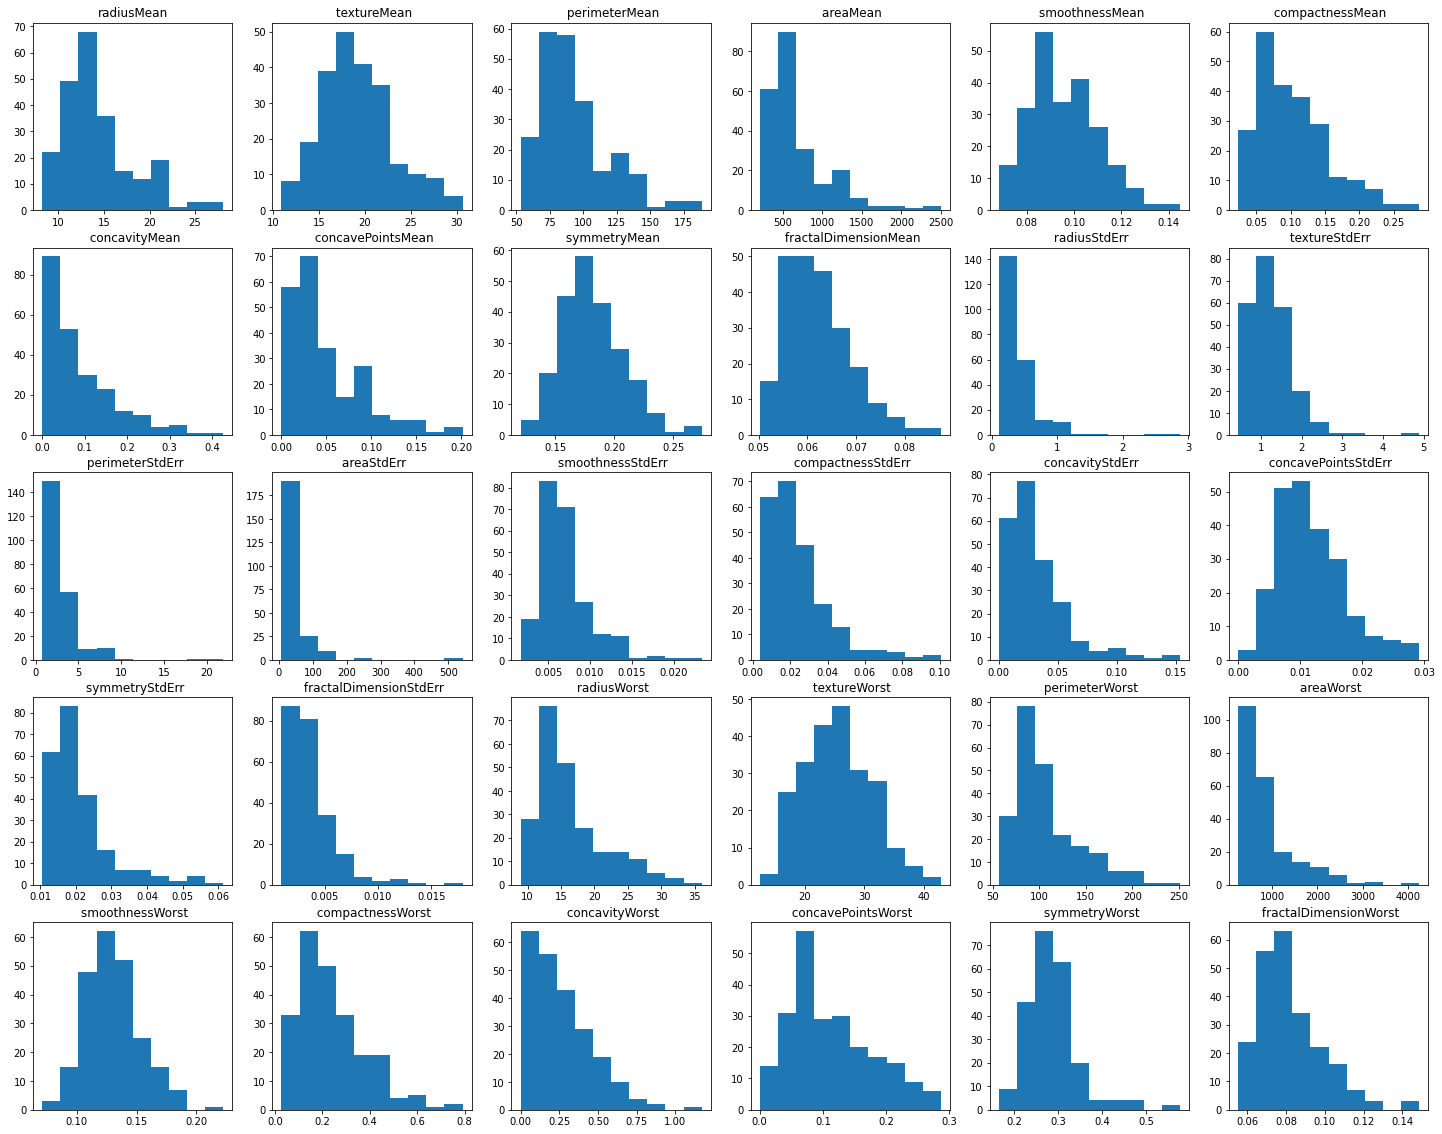

In [12]:
num_row = 6
num_col = 5
fig, ax = plt.subplots(num_col, num_row)
fig.set_figheight(20)
fig.set_figwidth(25)

for index, col in enumerate(X_model.columns):
    if pd.api.types.is_numeric_dtype(X[col]):
        ax[index // num_row, index % num_row].hist(X_model[col])
    else:
        ax[index // num_row, index % num_row].hist(X_model[col])
    ax[index // num_row, index % num_row].set_title(col)

## 6. Evaluation Metrics

In this report, we will use 3 metrics to compare the proformance of our data.

- Accuracy: This is the most common and stright forward one. It tell uses the percentage of the number of correct prediction.

- F1: This metric combind `precision` and `recall`. It is a better indicator to the performance of our model when the output class is imbalance like in our case where the churning is only 17%.

##  7. Naive Baseline Model

First, we create a baseline model by predicting only that the customer will not churn. We could see that the accuracy is pretty high because the number of churning samples are low.

In [13]:
most_occur_class = y_train.value_counts().idxmax()
baseline_predict = np.ones(len(y_val)) * most_occur_class
print(f'Accuracy of Baseline (predict with class {most_occur_class}):', metrics.accuracy_score(y_val, baseline_predict))

Accuracy of Baseline (predict with class False): 0.6304347826086957


## 8. Model#1 Logistic Regression


In [14]:
from sklearn.linear_model import LogisticRegression

### 8.1 Default Model
The default model is used to compare with our final model whether we can improve its performance or not.

In [15]:
default_logistic_regression_model = LogisticRegression(random_state=RANDOM_SEED, max_iter=10000)
score = cross_validate(default_logistic_regression_model, X_train, y_train, cv=5)
print('Mean accuracy of Logistic Regression(default)) cv:', np.mean(score['test_score']))

Mean accuracy of Logistic Regression(default)) cv: 0.9453453453453454


In [16]:
default_logistic_regression_model.fit(X_train, y_train)

LogisticRegression(max_iter=10000, random_state=1234)

### 8.2 Parameter Scaling
First we use various parameter scaling to find out which transformation could deliver the highest cross validation score.

In [17]:
pipe = Pipeline([
    ('scaler', None),
    ('classifier', LogisticRegression(random_state=RANDOM_SEED, max_iter=10000))
])
parameters = {'scaler': [None, StandardScaler(), MinMaxScaler(), Normalizer(), MaxAbsScaler()]}
grid = GridSearchCV(pipe, parameters, cv=5).fit(X_train, y_train)

We could see that **no scaler** and using `standardScaler()` provide close performance. We picked these two to transform our dataset because we know that scale of parameter could affect the performance of the regularized model

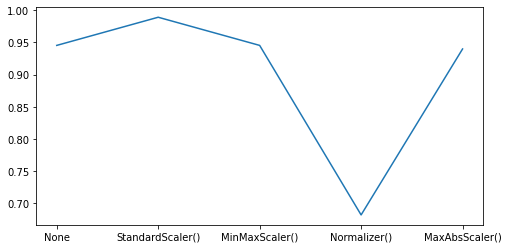

In [18]:
x_ticks = [str(p['scaler']) for p in grid.cv_results_['params']]
accuracy = grid.cv_results_['mean_test_score']
plot_params_accuracy(accuracy, x_ticks, 4, 8)

### 8.3 Tuning Parameter: solver / penalty
Note that we scale the data first with the best method in the previous step.

In [19]:
parameters = [
    {'solver': 'newton-cg', 'penalty': 'l2'},
    {'solver': 'newton-cg', 'penalty': 'none'},
    {'solver': 'lbfgs', 'penalty': 'l2'},
## There is a bug in the implementation so this configuration cannot be run.
#   {'solver': 'lbfgs', 'penalty': 'none'},
    {'solver': 'liblinear', 'penalty': 'l1'},
    {'solver': 'liblinear', 'penalty': 'l2'},
    {'solver': 'sag', 'penalty': 'l2'},
    {'solver': 'sag', 'penalty': 'none'},
    {'solver': 'saga', 'penalty': 'l1'},
    {'solver': 'saga', 'penalty': 'l2'},
    {'solver': 'saga', 'penalty': 'none'}
]

#### 8.3.2 Standard Scaler

In [20]:
accuracy = []

for parameter in parameters:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(random_state=RANDOM_SEED,
                                          max_iter=10000,
                                          solver=parameter['solver'],
                                          penalty=parameter['penalty']
                                         )
        )
    ])
    scores = cross_validate(pipe, X_train, y_train, cv=5)
    accuracy.append(np.mean(scores['test_score']))

Because there are several model with similar result. But the most successful are the one with 'L2' penalties.

Maximum accuracy for standard scaler is 0.9891891891891891
Best model is newton-cg_l2


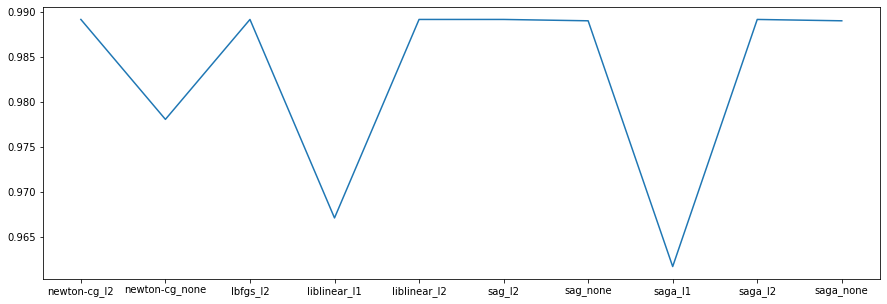

In [21]:
x_ticks = [f'{p["solver"]}_{p["penalty"]}' for p in parameters]
plot_params_accuracy(accuracy, x_ticks, height=5, width=15)
print('Maximum accuracy for standard scaler is', np.max(accuracy))
index = np.where(accuracy == np.amax(accuracy))
print(f'Best model is {x_ticks[index[0][0]]}')

### 8.4 Tuning Parameter: C
C is a regularized parameter. The smaller the more restrict.

In [22]:
C = [0.1, 0.3, 1, 3, 5, 10, 13, 15]

#### For standard scaling case

In [23]:
parameters = [
    {'solver': 'newton-cg', 'penalty': 'l2'}
]
accuracy = []
x_ticks = []

for parameter in parameters:
    for regularized_parameter in C:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(random_state=RANDOM_SEED,
                                              max_iter=10000,
                                              solver=parameter['solver'],
                                              penalty=parameter['penalty'],
                                              C=regularized_parameter
                                             )
            )
        ])
        scores = cross_validate(pipe, X_train, y_train, cv=5)
        accuracy.append(np.mean(scores['test_score']))
        x_ticks.append(f'{parameter["solver"]}_{parameter["penalty"]}_C={regularized_parameter}')

We could see that `solver=newton-cg`,`penalty=l2` and `C=13` perform the best.

Maximum accuracy for standard scaler is 0.9945945945945945
Best model is newton-cg_l2_C=13


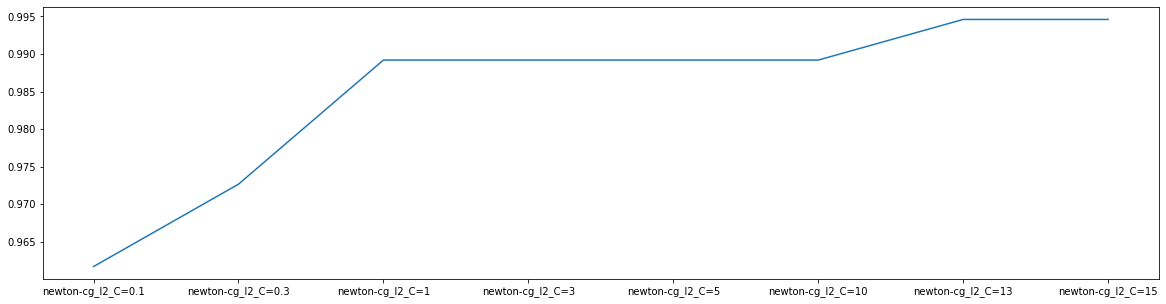

In [24]:
plot_params_accuracy(accuracy, x_ticks, height=5, width=20)
print('Maximum accuracy for standard scaler is', np.max(accuracy))
index = np.where(accuracy == np.amax(accuracy))
print(f'Best model is {x_ticks[index[0][0]]}')

### 8.5 Validation Set

#### 8.5.1 Default Model

In [25]:
default_regression_predict_val = default_logistic_regression_model.predict(X_val)
print('Accuracy of CV training set Logistic Regression(default)):',
      np.mean(cross_validate(default_logistic_regression_model, X_train, y_train, cv=5)['test_score']))
print('Accuracy of Validation set Logistic Regression(default)):',
      metrics.accuracy_score(y_val, default_regression_predict_val))
print('F1 Score of Validation set Logistic Regression(default)):',
      metrics.f1_score(y_val, default_regression_predict_val))

Accuracy of CV training set Logistic Regression(default)): 0.9453453453453454
Accuracy of Validation set Logistic Regression(default)): 0.9565217391304348
F1 Score of Validation set Logistic Regression(default)): 0.9375


#### 8.5.2 Optimal Model

#### 8.5.2.2 Standard Scaler

In [26]:
optimal_logistic_regression_standard_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=RANDOM_SEED,
                                      max_iter=10000,
                                      solver='newton-cg',
                                      penalty='l2',
                                      C=13
                                     )
    )
])
scores = cross_validate(optimal_logistic_regression_standard_pipe, X_train, y_train, cv=5)
print('optimal parameter training set score (standard scaler) cv:', np.mean(scores['test_score']))
optimal_logistic_regression_standard_pipe.fit(X_train, y_train)
optimal_logistic_regression_standard_predict_val = optimal_logistic_regression_standard_pipe.predict(X_val)
print('optimal parameter set score (standard scaler)',
      metrics.accuracy_score(y_val, optimal_logistic_regression_standard_predict_val))
print('F1 Score of Validation set Logistic Regression (standard scaler)):',
      metrics.f1_score(y_val, optimal_logistic_regression_standard_predict_val))

optimal parameter training set score (standard scaler) cv: 0.9945945945945945
optimal parameter set score (standard scaler) 0.9565217391304348
F1 Score of Validation set Logistic Regression (standard scaler)): 0.9375


We could see that our standard scaling case provide the best performace in the training set. But it performs at the same level with the default parameters on the validation set. Our chosen parameters are `solver='lbfgs'`, `penalty='l2'`, and `C=13`

## 9. Model#2 K-Nearest Neighbor

In [27]:
from sklearn.neighbors import KNeighborsClassifier

### 9.1 Default Model

In [28]:
default_knn_classifier = KNeighborsClassifier()
score = cross_validate(default_knn_classifier, X_train, y_train, cv=5)
print('Mean accuracy of K-Nearest Neighbor(default)) cv:', np.mean(score['test_score']))

Mean accuracy of K-Nearest Neighbor(default)) cv: 0.9453453453453454


In [29]:
default_knn_classifier.fit(X_train, y_train)

KNeighborsClassifier()

### 9.2 Parameter Scaling

In [30]:
pipe = Pipeline([
    ('scaler', None),
    ('classifier', KNeighborsClassifier())
])
parameters = {'scaler': [None, StandardScaler(), MinMaxScaler(), Normalizer(), MaxAbsScaler()]}
grid = GridSearchCV(pipe, parameters, cv=5).fit(X_train, y_train)

We see that Standard Scaler performs the best.

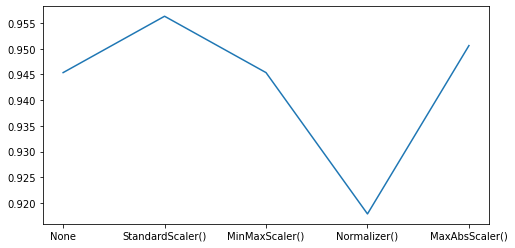

In [31]:
x_ticks = [str(p['scaler']) for p in grid.cv_results_['params']]
accuracy = grid.cv_results_['mean_test_score']
plot_params_accuracy(accuracy, x_ticks, 4, 8)

### 9.3 Tuning Parameter: n_neighbors and p

#### 9.3.1 Standard Scaler

In [32]:
p_list = [1, 2, 3]
n_neighbors_lists = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [33]:
accuracy = []
x_ticks = []
for p in p_list:
    for n_neighbors in n_neighbors_lists:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', KNeighborsClassifier(
                p=p,
                n_neighbors=n_neighbors
            ))
        ])
        scores = cross_validate(pipe, X_train, y_train, cv=5)
        accuracy.append(np.mean(scores['test_score']))
        x_ticks.append(f'p={p}_n_neighbors={n_neighbors}')

In [34]:
pd.DataFrame({'setting': x_ticks, 'accuracy': accuracy}).sort_values('accuracy', ascending=False).head()

,setting,accuracy
14,p=2_n_neighbors=5,0.956306
3,p=1_n_neighbors=4,0.956306
4,p=1_n_neighbors=5,0.956306
28,p=3_n_neighbors=9,0.956156
26,p=3_n_neighbors=7,0.956156


The best parameter set for the standard scaler case is `p=2` and `n_neighbors=5`.

### 9.4 Validation Set

#### 9.4.1 Default Model

In [35]:
knn_predict_val = default_knn_classifier.predict(X_val)
print('Accuracy of CV training set KNN(default)):',
      np.mean(cross_validate(default_knn_classifier, X_train, y_train, cv=5)['test_score']))
print('Accuracy of Validation set KNN(default)):',
      metrics.accuracy_score(y_val, knn_predict_val))
print('F1 Score of Validation set KNN(default)):',
      metrics.f1_score(y_val, knn_predict_val))

Accuracy of CV training set KNN(default)): 0.9453453453453454
Accuracy of Validation set KNN(default)): 0.9347826086956522
F1 Score of Validation set KNN(default)): 0.9090909090909091


#### 9.4.2 Optimal Model

For standard scaler

In [36]:
stanndard_optimal_knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(
        p=2,
        n_neighbors=5
    ))
])
stanndard_optimal_knn_pipe.fit(X_train, y_train)
scores = cross_validate(stanndard_optimal_knn_pipe, X_train, y_train, cv=5)
print('Optimal parameter training set score KNN (standard scaler):',
      np.mean(scores['test_score'])
)
optimal_knn_pipe_predict_val = stanndard_optimal_knn_pipe.predict(X_val)
print('Optimal parameter set score KNN (standard scaler) validation:',
      metrics.accuracy_score(y_val, optimal_knn_pipe_predict_val)
)
print('F1 Score of Validation set KNN (standard scaler)) validation:',
      metrics.f1_score(y_val, knn_predict_val))

Optimal parameter training set score KNN (standard scaler): 0.9563063063063064
Optimal parameter set score KNN (standard scaler) validation: 0.9130434782608695
F1 Score of Validation set KNN (standard scaler)) validation: 0.9090909090909091


The standard scaler KNN with parameter `p=2` and `n_neighbors=5` performs the best for the training set. But it performs similarly with the default model for the validation set.

## 10. Model#3 Random Forest

In [37]:
from sklearn.ensemble import RandomForestClassifier

### 10.1 The default Model

In [38]:
default_random_forest_classifier = RandomForestClassifier(random_state=RANDOM_SEED)
score = cross_validate(default_random_forest_classifier, X_train, y_train, cv=5)
print('Mean accuracy of Random Forest(default)) cv:', np.mean(score['test_score']))
default_random_forest_classifier.fit(X=X_train, y=y_train)

Mean accuracy of Random Forest(default)) cv: 0.9453453453453454


RandomForestClassifier(random_state=1234)

### 10.2 Parameter Scaling

In [39]:
pipe = Pipeline([
    ('scaler', None),
    ('classifier', RandomForestClassifier(random_state=RANDOM_SEED))
])
parameters = {'scaler': [None, StandardScaler(), MinMaxScaler(), Normalizer(), MaxAbsScaler()]}
grid = GridSearchCV(pipe, parameters, cv=5).fit(X_train, y_train)

We could see that for random forest the `Normalizer` performs the best.

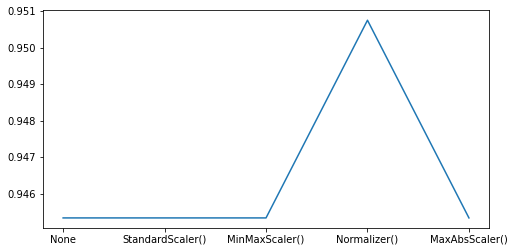

In [40]:
x_ticks = [str(p['scaler']) for p in grid.cv_results_['params']]
accuracy = grid.cv_results_['mean_test_score']
plot_params_accuracy(accuracy, x_ticks, 4, 8)

### 10.3 Tuning Parameter: criterion

In [41]:
accuracy = []
criterion_list = ['entropy', 'gini']
for criteria in criterion_list:
    pipe = Pipeline([
        ('scaler', Normalizer()),
        ('classifier', RandomForestClassifier(
            criterion=criteria,
            random_state=RANDOM_SEED
        ))
    ])
    random_forest_classifier = RandomForestClassifier(criterion=criteria, random_state=RANDOM_SEED)
    random_forest_model = random_forest_classifier.fit(X=X_train, y=y_train)
    predict_val = random_forest_model.predict(X_val)
    accuracy.append(metrics.accuracy_score(y_val, predict_val))

We could see that `gini` work much better.

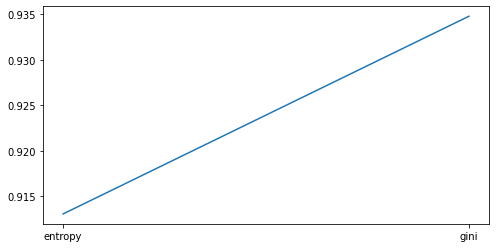

In [42]:
plot_params_accuracy(accuracy, criterion_list, 4, 8)

### 10.4 Tuning Parameter: n_estimators and max_depth

In [43]:
accuracy = []
n_estimator_list = [10, 50, 100, 300, 500, 1000, 3000, 10000]
max_depth_list = [3, 5, 10, 30, 100, 300, None]
x_ticks = []
for n_estimator in n_estimator_list:
    for max_depth in max_depth_list:
        pipe = Pipeline([
            ('scaler', Normalizer()),
            ('classifier', RandomForestClassifier(
                n_estimators=n_estimator,
                max_depth=max_depth,
                criterion='gini',
                random_state=RANDOM_SEED
            ))
        ])
        accuracy.append(np.mean(cross_validate(random_forest_classifier, X_train, y_train, cv=5, n_jobs=-1)['test_score']))
        x_ticks.append(f'n_estimator={n_estimator}_max_depth={max_depth}')

We could see that there are several model that result in the same level. We pick the simplest one from here.

In [44]:
pd.DataFrame({'setting': x_ticks, 'accuracy': accuracy}).sort_values('accuracy', ascending=False).head()

,setting,accuracy
0,n_estimator=10_max_depth=3,0.945345
1,n_estimator=10_max_depth=5,0.945345
30,n_estimator=500_max_depth=10,0.945345
31,n_estimator=500_max_depth=30,0.945345
32,n_estimator=500_max_depth=100,0.945345


### 10.5 Validation Set

#### 10.5.1 Default Model

In [45]:
default_random_forest_val_predict = default_random_forest_classifier.predict(X_val)
metrics.accuracy_score(y_val, default_random_forest_val_predict)

print('Accuracy of CV training set Random Forest(default)):',
      np.mean(cross_validate(default_random_forest_classifier, X_train, y_train, cv=5)['test_score']))
print('Accuracy of Validation set Random Forest(default)):',
      metrics.accuracy_score(y_val, default_random_forest_val_predict))
print('F1 Score of Validation set Random Forest(default)):',
      metrics.f1_score(y_val, default_random_forest_val_predict))

Accuracy of CV training set Random Forest(default)): 0.9453453453453454
Accuracy of Validation set Random Forest(default)): 0.9347826086956522
F1 Score of Validation set Random Forest(default)): 0.9032258064516129


#### 10.5.2 Optimal Model

In [46]:
optimal_random_forest_pipe = Pipeline([
    ('scaler', Normalizer()),
    ('classifier', RandomForestClassifier(
        n_estimators=10,
        max_depth=3,
        criterion='gini',
        random_state=RANDOM_SEED
    ))
])

optimal_random_forest_pipe.fit(X_train, y_train)
optimal_random_forest_val_predict = optimal_random_forest_pipe.predict(X_val)
metrics.accuracy_score(y_val, optimal_random_forest_val_predict)

print('Accuracy of CV training set Random Forest(optimal)):',
      np.mean(cross_validate(optimal_random_forest_pipe, X_train, y_train, cv=5)['test_score']))
print('Accuracy of Validation set Random Forest(optimal)):',
      metrics.accuracy_score(y_val, optimal_random_forest_val_predict))
print('F1 Score of Validation set Random Forest(optimal)):',
      metrics.f1_score(y_val, optimal_random_forest_val_predict))

Accuracy of CV training set Random Forest(optimal)): 0.9343843843843844
Accuracy of Validation set Random Forest(optimal)): 0.9347826086956522
F1 Score of Validation set Random Forest(optimal)): 0.9032258064516129


We found that the optimal forest result in almost the same accuracy level but because the optimal model is much simpler. We pick the optimal model.

## 11. XGBoost

Because all of the model predict this dataset quite well already and we include this algorithms as well. XGBoost is similar to the random forest but it implement some regularized method which makes this algorithm generalize well. 

We didn't include the code here because it require to be trained with a GPU.

```python
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', xgb.XGBClassifier(
        n_estimators=300, eval_metric='logloss',
        gamma=0.2,
        max_depth=3,
        colsample_bytree=0.5,
        tree_method='gpu_hist',
        gpu_id=1
    ))
])

cv_results = cross_validate(pipe, X_train, y_train, cv=5, n_jobs=-1)
print('cv_results', np.mean(cv_results['test_score']))
```

## Test Set Evaluation

Here we choose a model with the best parameters set from eash machine learning algorithms based on the validation set performance. We retrain the models again with full modelling data and evaluate them with the test set.

### Naive Baseline Model

In [47]:
most_occur_class = y_train.value_counts().idxmax()
baseline_predict_test = np.ones(len(y_test)) * most_occur_class
print(f'Accuracy of Baseline (predict with class {most_occur_class}) test set:',
      metrics.accuracy_score(y_test, baseline_predict_test))
print('F1 Score of Baseline test set:',
      metrics.f1_score(y_test, baseline_predict_test))

Accuracy of Baseline (predict with class False) test set: 0.5964912280701754
F1 Score of Baseline test set: 0.0


### Logistic Regression

In [48]:
final_optimal_logistic_regression_pipe = Pipeline([
    ('classifier', LogisticRegression(random_state=RANDOM_SEED,
                                      max_iter=10000,
                                      solver='newton-cg',
                                      penalty='l2',
                                      C=13
                                     )
    )
])
final_optimal_logistic_regression_pipe.fit(X_model, y_model)

logistic_regression_predict_test = final_optimal_logistic_regression_pipe.predict(X_test)
print('Accuracy of test set Logistic Regression (optimal)):',
    metrics.accuracy_score(y_test, logistic_regression_predict_test))
print('F1 Score of test set Logistic Regression (optimal)):',
      metrics.f1_score(y_test, logistic_regression_predict_test))

Accuracy of test set Logistic Regression (optimal)): 0.9649122807017544
F1 Score of test set Logistic Regression (optimal)): 0.9545454545454545


### K-Nearest Neighbor

In [49]:
final_min_max_optimal_knn_pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', KNeighborsClassifier(
        p=2,
        n_neighbors=5
    ))
])
final_min_max_optimal_knn_pipe.fit(X_model, y_model)


knn_predict_test = final_min_max_optimal_knn_pipe.predict(X_test)


print('Accuracy of test set KNN (optimal)):',
      metrics.accuracy_score(y_test, knn_predict_test))
print('F1 Score of test set KNN (optimal)):',
      metrics.f1_score(y_test, knn_predict_test))

Accuracy of test set KNN (optimal)): 0.9473684210526315
F1 Score of test set KNN (optimal)): 0.9302325581395349


### Random Forest

In [50]:
optimal_random_forest_classifier = Pipeline([
    ('scaler', Normalizer()),
    ('classifier', RandomForestClassifier(
        n_estimators=10,
        max_depth=3,
        criterion='gini',
        random_state=RANDOM_SEED
    ))
])

optimal_random_forest_classifier.fit(X_model, y_model)

optimal_random_forest_test_predict = optimal_random_forest_classifier.predict(X_test)
metrics.accuracy_score(y_test, optimal_random_forest_test_predict)
metrics.f1_score(y_test, optimal_random_forest_test_predict)

print('Accuracy of test set Random Forest (optimal)):',
      metrics.accuracy_score(y_test, optimal_random_forest_test_predict))
print('F1 Score of test set Random Forest (optimal)):',
      metrics.f1_score(y_test, optimal_random_forest_test_predict))

Accuracy of test set Random Forest (optimal)): 0.9473684210526315
F1 Score of test set Random Forest (optimal)): 0.9302325581395349


## Summary

We can see that the accuracy of each method aren't differ very much but the Logistic Regression slightly outperform other methods.

The final parameter are `solver='newton-cg'`, `penalty='l2'` and `C=13`.